In [1]:
# Import necessary libraries and modules
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import kaggle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from pathlib import Path



c:\Users\eddie\anaconda3\envs\data_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Connecting src folder
notebook_dir = Path.cwd()
sys.path.append("..")
# from src.data_utils import NECESSARY METHODS GO HERE
from src.chatbot_model import EquityChatbotModel


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eddie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Download and update dataset
dataset = 'adrianjuliusaluoch/hourly-crypto-stocks-market-data'
csv_file = 'stocks.csv'

kaggle.api.authenticate()
kaggle.api.dataset_download_files(dataset, path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/adrianjuliusaluoch/hourly-crypto-stocks-market-data


In [4]:
# Read financial dataset and initial assessment
df = pd.read_csv("stocks.csv")
df = df.query("name != 'Citigroup'")
df.head()
df.info()
df.describe()
df.tail()
df['name'].nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 263652 entries, 0 to 268677
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  263652 non-null  object 
 1   name       263652 non-null  object 
 2   last       263652 non-null  float64
 3   high       263652 non-null  float64
 4   low        263652 non-null  float64
 5   chg_       263652 non-null  float64
 6   chg_%      263652 non-null  object 
 7   vol_       263652 non-null  object 
 8   time       263652 non-null  object 
dtypes: float64(4), object(5)
memory usage: 20.1+ MB


30

In [5]:
# Pre-clean dataset
df.head(10)

,timestamp,name,last,high,low,chg_,chg_%,vol_,time
0,2025-12-16 19:30:00,Coca-Cola,70.69,71.30,70.54,-0.28,-0.40%,5.02M,11:28:01
1,2025-12-16 19:30:00,Walt Disney,112.35,112.85,110.86,1.86,+1.68%,4.44M,11:28:34
2,2025-12-16 19:30:00,3M,163.38,167.00,162.84,-2.33,-1.40%,767.25K,11:28:53
3,2025-12-16 19:30:00,Microsoft,473.38,475.19,470.88,-1.44,-0.30%,5.62M,11:28:34
4,2025-12-16 19:30:00,Merck&amp;Co,98.04,100.37,96.79,-2.23,-2.22%,5.41M,11:28:50
5,2025-12-16 19:30:00,McDonald’s,316.31,320.58,315.98,-2.42,-0.76%,782.66K,11:27:59
6,2025-12-16 19:30:00,Boeing,207.51,208.65,204.39,2.01,+0.98%,2.24M,11:28:40
7,2025-12-16 19:30:00,Caterpillar,592.57,598.66,587.61,2.81,+0.48%,666.2K,11:28:54
8,2025-12-16 19:30:00,Chevron,147.20,148.82,146.67,-2.60,-1.74%,2.88M,11:28:54
9,2025-12-16 19:30:00,Cisco,77.75,78.61,77.69,-0.50,-0.64%,3.42M,11:27:43


In [6]:
# Cleaning and preprocessing dataset

df = df.dropna()

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['name'] = df['name'].str.replace('&amp;', '&')

df['chg_%'] = df['chg_%'].str.replace('%', '')
df['chg_%'] = df['chg_%'].astype('float')

def parse_volume(vol):
    vol = vol.replace('M', 'e6').replace('K', 'e3')
    return float(eval(vol))

df['vol_'] = df['vol_'].apply(parse_volume)
df.head(10)
# Post-clean dataset


,timestamp,name,last,high,low,chg_,chg_%,vol_,time
0,2025-12-16 19:30:00,Coca-Cola,70.69,71.30,70.54,-0.28,-0.40,5020000.0,11:28:01
1,2025-12-16 19:30:00,Walt Disney,112.35,112.85,110.86,1.86,1.68,4440000.0,11:28:34
2,2025-12-16 19:30:00,3M,163.38,167.00,162.84,-2.33,-1.40,767250.0,11:28:53
3,2025-12-16 19:30:00,Microsoft,473.38,475.19,470.88,-1.44,-0.30,5620000.0,11:28:34
4,2025-12-16 19:30:00,Merck&Co,98.04,100.37,96.79,-2.23,-2.22,5410000.0,11:28:50
5,2025-12-16 19:30:00,McDonald’s,316.31,320.58,315.98,-2.42,-0.76,782660.0,11:27:59
6,2025-12-16 19:30:00,Boeing,207.51,208.65,204.39,2.01,0.98,2240000.0,11:28:40
7,2025-12-16 19:30:00,Caterpillar,592.57,598.66,587.61,2.81,0.48,666200.0,11:28:54
8,2025-12-16 19:30:00,Chevron,147.20,148.82,146.67,-2.60,-1.74,2880000.0,11:28:54
9,2025-12-16 19:30:00,Cisco,77.75,78.61,77.69,-0.50,-0.64,3420000.0,11:27:43


In [7]:
df['name'].unique()

array(['Coca-Cola', 'Walt Disney', '3M', 'Microsoft', 'Merck&Co',
       'McDonald’s', 'Boeing', 'Caterpillar', 'Chevron', 'Cisco',
       'JPMorgan', 'Goldman Sachs', 'Amazon.com', 'Home Depot',
       'Honeywell', 'IBM', 'J&J', 'Apple', 'Amgen', 'American Express',
       'NVIDIA', 'Nike', 'P&G', 'Salesforce Inc', 'Sherwin-Williams',
       'Travelers', 'UnitedHealth', 'Verizon', 'Visa A', 'Walmart'],
      dtype=object)

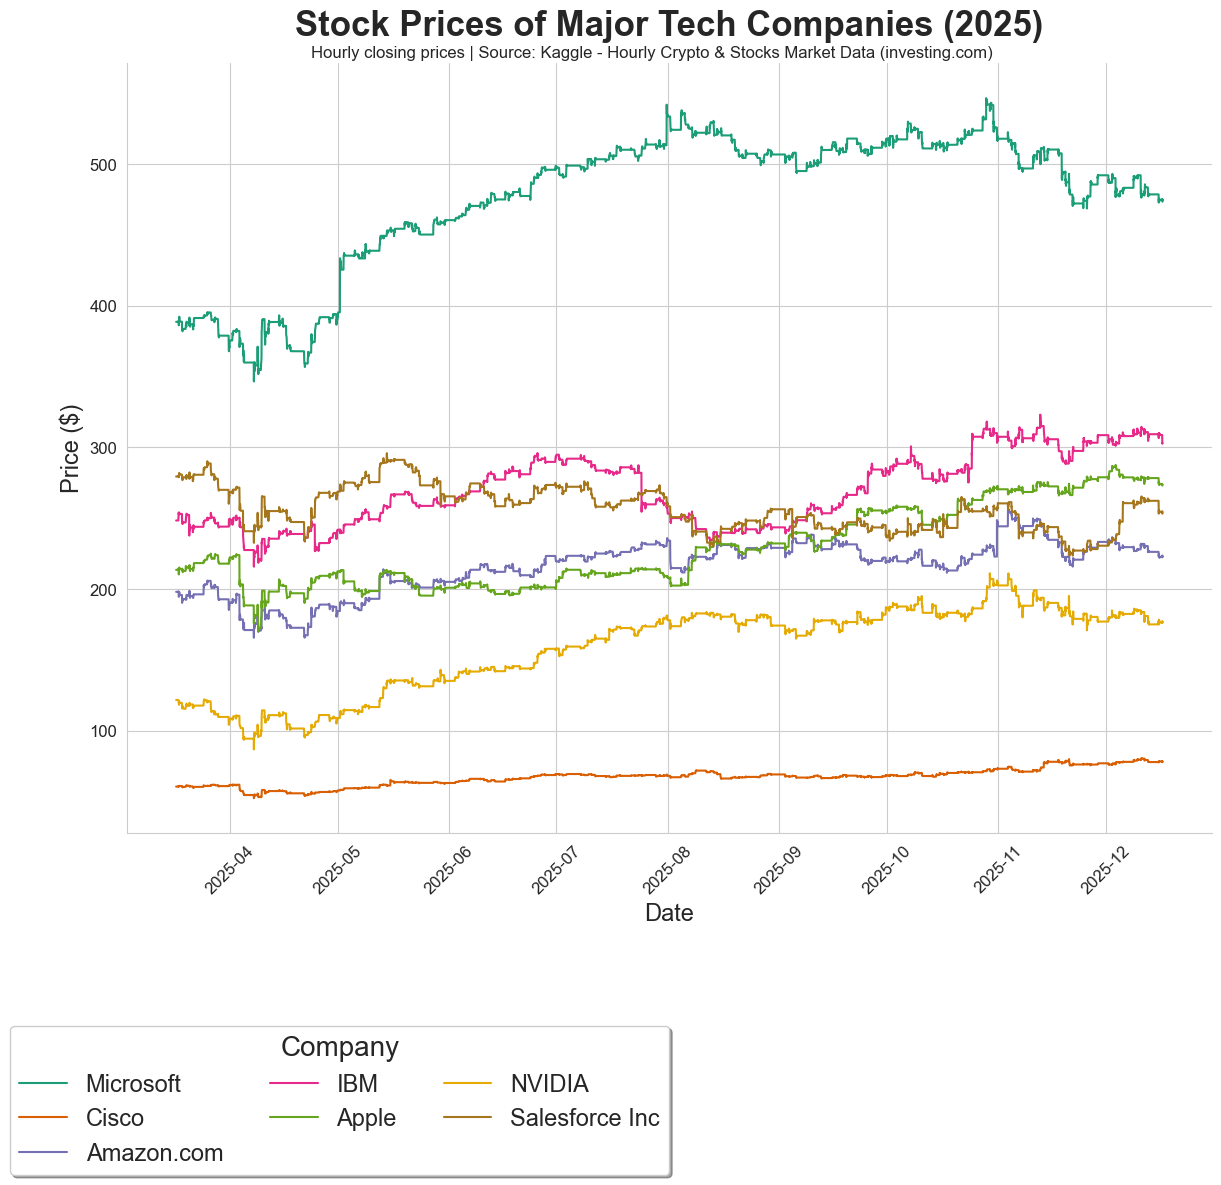

In [8]:
# Visualization #1: Major technology company stock prices over 2025

tech_comps = [
    'Microsoft',
    'Apple',
    'NVIDIA',
    'Amazon.com',
    'Cisco',
    'IBM',
    'Salesforce Inc'
]
df_tech = df[df['name'].isin(tech_comps)]

sns.set_style('whitegrid')
sns.set_palette('Dark2')
plt.figure(figsize=(14, 10))
sns.lineplot(data=df_tech, x='timestamp', y='last', hue='name')
plt.title('Stock Prices of Major Tech Companies (2025)', fontsize=25, weight='bold', pad=20)
plt.suptitle('Hourly closing prices | Source: Kaggle - Hourly Crypto & Stocks Market Data (investing.com)', fontsize=12, y=0.898)
plt.xlabel('Date', fontsize = 17)
plt.ylabel('Price ($)', fontsize = 17)
plt.xticks(rotation=45, fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(
    title = 'Company', 
    loc='best',
    bbox_to_anchor=(0.5, -.25),
    ncol = 3,
    fancybox=True,
    shadow = True,
    borderaxespad=0,
    fontsize = 17,
    title_fontsize = 20
    )
sns.despine()
plt.show()


C:\Users\eddie\AppData\Local\Temp\ipykernel_31256\1490155393.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_growth, y='name', x ='growth', palette='Dark2')


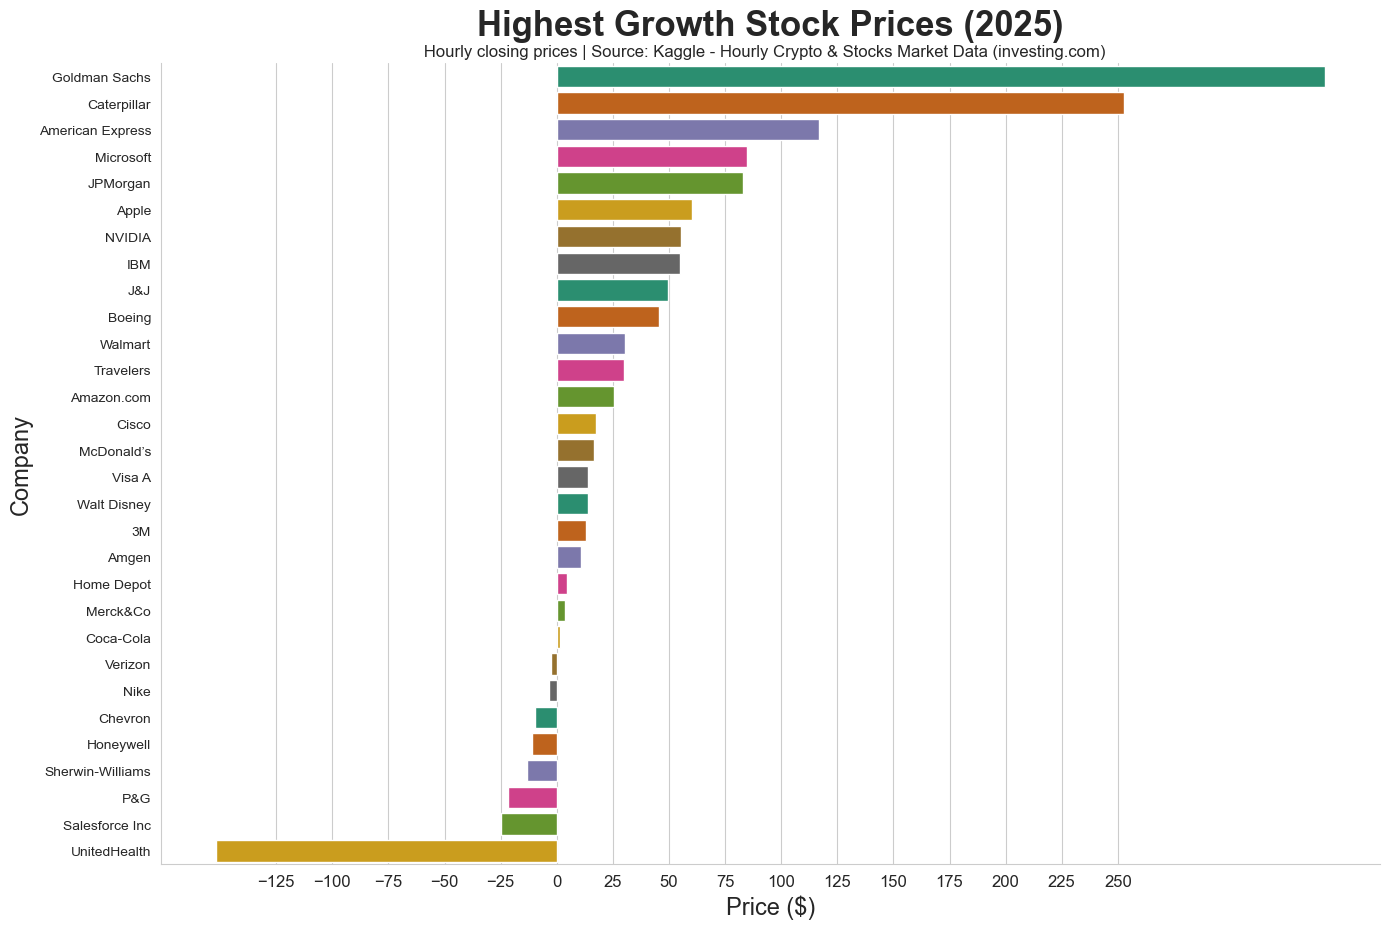

In [9]:
#  Visualization #2 - Highest growth stock prices over 2025

df_sorted = df.sort_values(by=['name', 'timestamp'])
first_close = df_sorted.groupby('name').first()
last_close = df_sorted.groupby('name').last()
changes = last_close['last'] - first_close['last']
changes = changes.sort_values(ascending=False)
df_growth = changes.reset_index()
df_growth.columns = ['name', 'growth']
df_growth

sns.set_style('whitegrid')
sns.set_palette('Dark2')
plt.figure(figsize=(14, 10))
ax = sns.barplot(data=df_growth, y='name', x ='growth', palette='Dark2')
plt.title('Highest Growth Stock Prices (2025)', fontsize=25, weight='bold', pad=20, x = 0.5)
plt.suptitle('                              Hourly closing prices | Source: Kaggle - Hourly Crypto & Stocks Market Data (investing.com)', fontsize=12, y=0.920, x = 0.5)
plt.ylabel('Company', fontsize = 17)
plt.xlabel('Price ($)', fontsize = 17)
plt.xticks(ticks = [-125, -100, -75, -50, -25, 0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250], fontsize = 12)

plt.tight_layout(rect=[0, 0.03, 1, 1])
sns.despine()
plt.show()

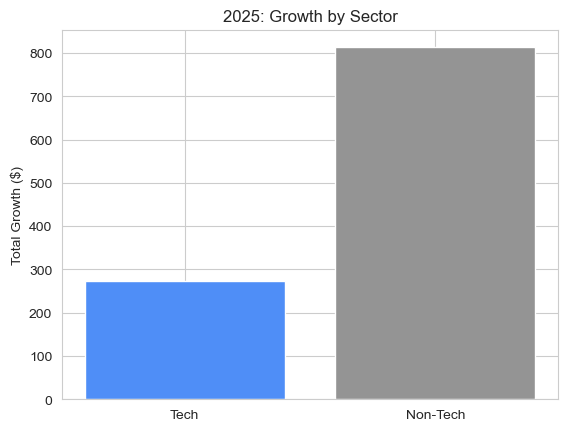

In [10]:
#  Visualization #3: Which type of company has the highest growth over 2025: Tech or Non-Tech?
#  Part 1: Bar Plot of Total Growth (sum)

df_nontech = df[df['name'].isin(tech_comps) == False]
df_nontech = df_nontech.sort_values(by=['name', 'timestamp'])
first_close = df_nontech.groupby('name').first()
last_close = df_nontech.groupby('name').last()
changes = last_close['last'] - first_close['last']
changes = changes.sort_values(ascending=False)

df_tech = df_tech.sort_values(by = ['name', 'timestamp'])
fc_tech = df_tech.groupby('name').first()
lc_tech = df_tech.groupby('name').last()
changes_tech = lc_tech['last'] - fc_tech['last']
changes_tech = changes_tech.sort_values(ascending=False)

df_growth = changes.reset_index()
df_growth.columns = ['name', 'growth']
df_growth

df_tech_growth = changes_tech.reset_index()
df_tech_growth.columns = ['name', 'growth']
df_tech_growth

total_tech_growth = df_tech_growth['growth'].sum()
total_nontech_growth = df_growth['growth'].sum()
plt.bar(['Tech', 'Non-Tech'], [total_tech_growth, total_nontech_growth], color=['#4f8ef7', '#949494'])
plt.ylabel("Total Growth ($)")
plt.title("2025: Growth by Sector")
plt.show()


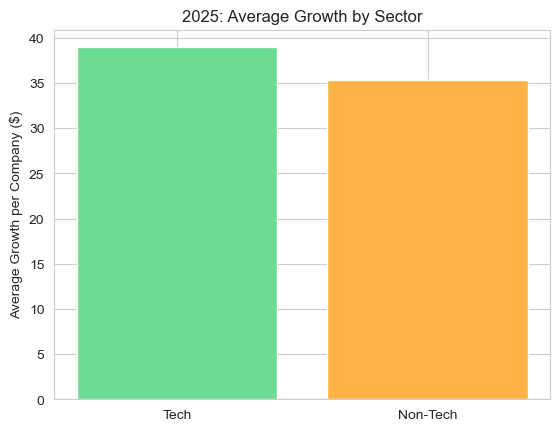

In [11]:
#  Visualization #3
#  Part 2: Mean Growth by Sector -- Bar Plot

mean_tech_growth = df_tech_growth['growth'].mean()
mean_nontech_growth = df_growth['growth'].mean()
plt.bar(['Tech', 'Non-Tech'], [mean_tech_growth, mean_nontech_growth], color=['#6cdb93', '#ffb347'])
plt.ylabel("Average Growth per Company ($)")
plt.title("2025: Average Growth by Sector")
plt.show()

C:\Users\eddie\AppData\Local\Temp\ipykernel_31256\3727436521.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sector_growth, x='sector', y='growth', palette='Set2')


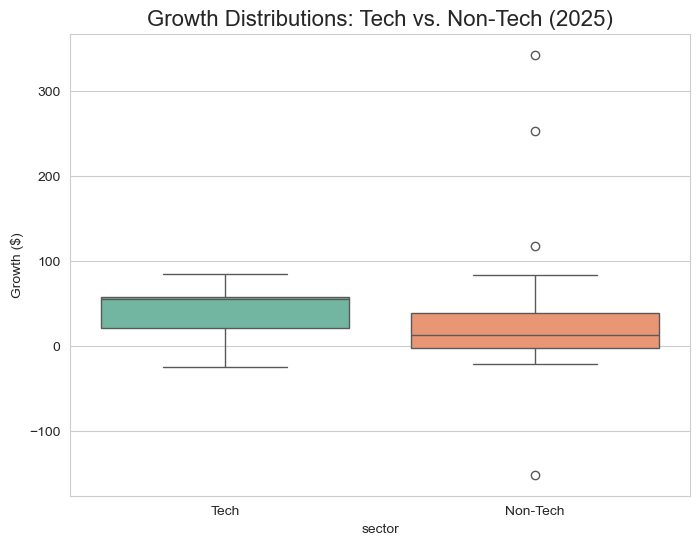

In [12]:
#  Visualization #3
#  Part 3: Box Plot: Distribution

sector_growth = pd.concat([
    df_tech_growth.assign(sector='Tech'),
    df_growth.assign(sector='Non-Tech')
])
plt.figure(figsize=(8,6))
sns.boxplot(data=sector_growth, x='sector', y='growth', palette='Set2')
plt.title("Growth Distributions: Tech vs. Non-Tech (2025)", fontsize=16)
plt.ylabel("Growth ($)")
plt.show()

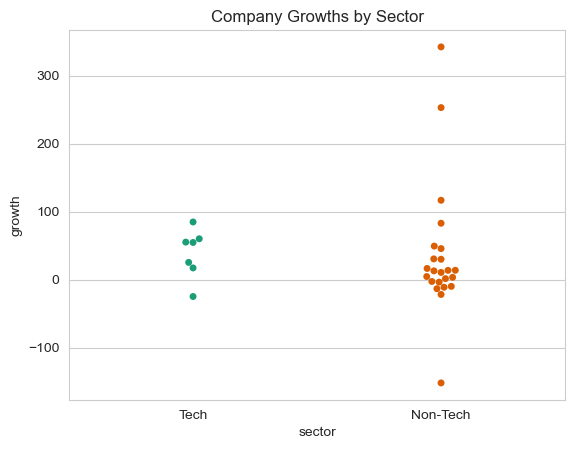

In [13]:
#  Visualization #3
#  Part 4: Beeswarm/Scatter of all companies

sns.swarmplot(data=sector_growth, x='sector', y='growth', hue='sector')
plt.title("Company Growths by Sector")
plt.show()

Mean Squared Error: 0.7803389500491343
R2 Score: 0.9947200767526664


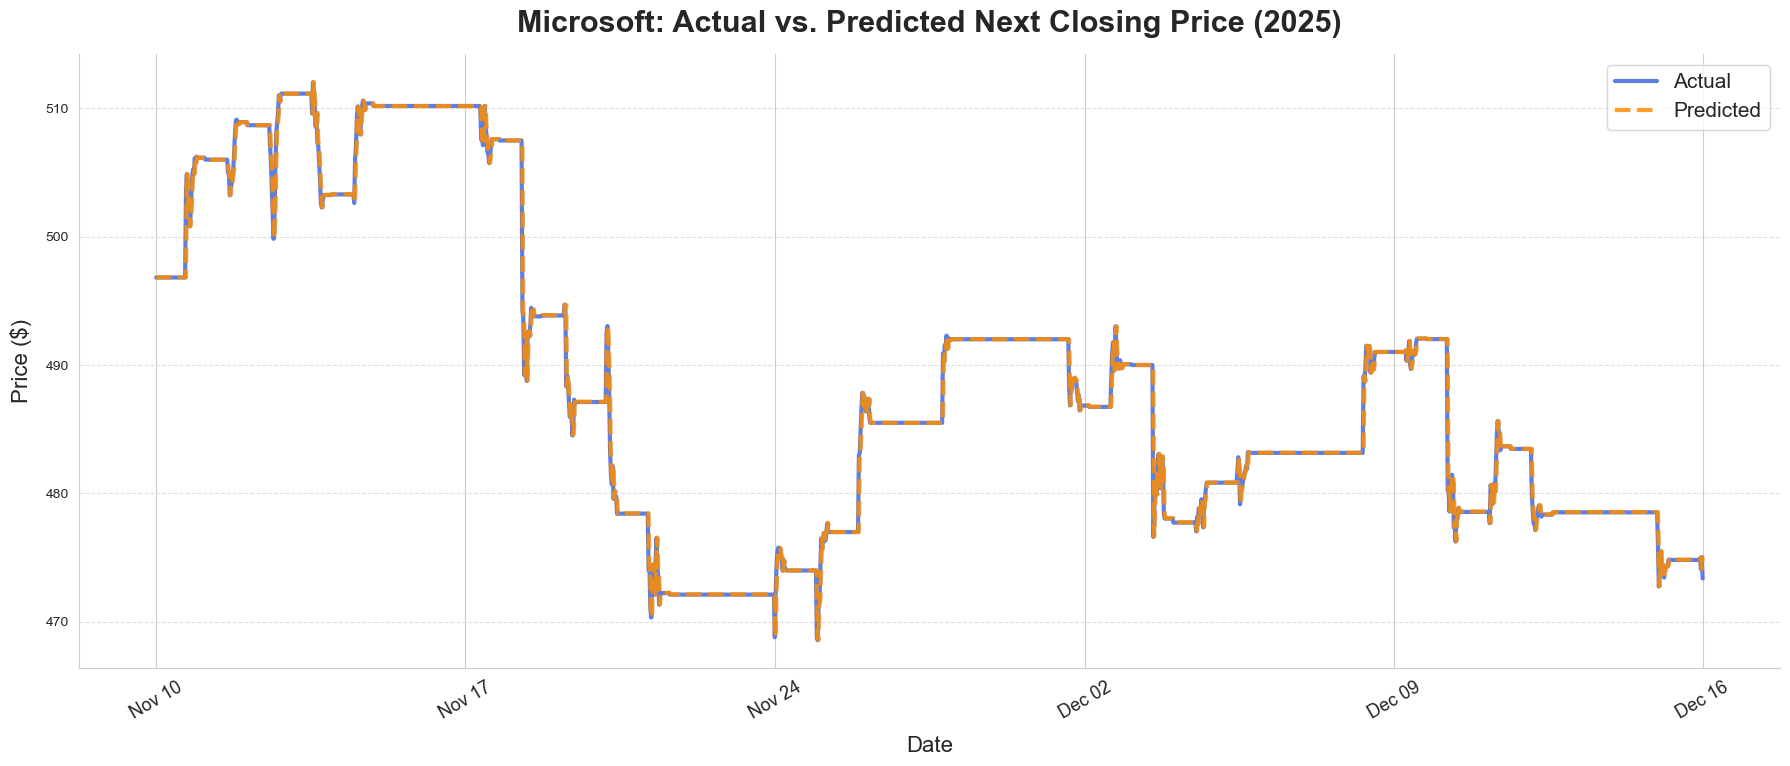

In [14]:
#  Prediction task #1: Next closing price of Microsoft over 2025

df_microsoft = df[df['name'] == 'Microsoft']
df_microsoft = df_microsoft.sort_values(by=['timestamp'])
df_microsoft['last_lag1'] = df_microsoft['last'].shift(1)
df_microsoft['chg_lag1'] = df_microsoft['chg_'].shift(1)
df_microsoft['vol_lag1'] = df_microsoft['vol_'].shift(1)

df_microsoft = df_microsoft.dropna()
X = df_microsoft[['last_lag1', 'chg_lag1', 'vol_lag1']]
Y = df_microsoft['last']

train_size = int(len(df_microsoft) * 0.8)

X_train = X[:train_size]
Y_train = Y[:train_size]
X_test = X[train_size:]
Y_test = Y[train_size:]

model = LinearRegression()
model.fit(X_train, Y_train)

predictions = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print("Mean Squared Error:", mean_squared_error(Y_test, predictions))
print("R2 Score:", r2_score(Y_test, predictions))

test_dates = df_microsoft['timestamp'].iloc[train_size:]

sns.set_style("whitegrid")
plt.figure(figsize=(18, 8))

plt.plot(test_dates, Y_test.values, label="Actual", linewidth=3, color="royalblue", alpha=0.85)
plt.plot(test_dates, predictions, label="Predicted", linewidth=3, color="darkorange", linestyle="--", alpha=0.85)

plt.legend(fontsize=15, frameon=True)
plt.title("Microsoft: Actual vs. Predicted Next Closing Price (2025)", fontsize=22, weight='bold', pad=16)
plt.xlabel("Date", fontsize=16, labelpad=10)
plt.ylabel("Price ($)", fontsize=16, labelpad=10)

num_xticks = 6
total_test_dates = len(test_dates)
xticks_index = np.linspace(0, total_test_dates-1, num_xticks).astype(int)
xticks_dates = test_dates.iloc[xticks_index].dt.strftime('%b %d')
plt.xticks(test_dates.iloc[xticks_index], xticks_dates, rotation=30, fontsize=13)

plt.tight_layout(rect=[0, 0.03, 1, 1])
sns.despine()

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()





In [1]:
# Training Equity
import sys
sys.path.append("..")

from src.chatbot_model import EquityChatbot

bot = EquityChatbot('../src/chatbot_model.pth')

tests = [
     "Hello",
    "Hi there",
    "Which stock grew the most?",
    "Show me the top growth",
    "What is the price",
    "Trading volume",
    "Thanks",
    "Goodbye",
    "Help me",
    "whxirh32981h (random text)" 
]

for test in tests:
    print(f"User: {test}")
    response = bot.get_response(test)
    print(f"Equity: {response}\n")



User: Hello
Equity: Hello, my name's Equity!

User: Hi there
Equity: Hi there! I'm Equity! Ask me questions about the top stock companies!

User: Which stock grew the most?
Equity: I'll find the top performing stocks.

User: Show me the top growth
Equity: Let me analyze the growth data for you.

User: What is the price
Equity: Ask me about stock prices, growth rates, trading volumes, or to compare companies!

User: Trading volume
Equity: Let me check the trading volume data.

User: Thanks
Equity: You're welcome!

User: Goodbye
Equity: Take care! If you have stock questions, you know where to find me!

User: Help me
Equity: Ask me about stock prices, growth rates, trading volumes, or to compare companies!

User: whxirh32981h (random text)
Equity: I'm sorry, I am not sure I understand. Can you rephrase that?



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\eddie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
